# KNN model - evaluacija

## 1. Uvod
Ovaj notebook implementira klasifikaciju audio fajlova koristeći **KNN**. 
Koristićemo Mel spektrogram kao feature.  
**Osnovna ideja:**
KNN je jednostavan, ali moćan algoritam za klasifikaciju i regresiju koji radi po principu sličnosti. Za datu instancu (novi podatak) algoritam gleda K najbližih tačaka u skupu podataka i na osnovu njih donosi odluku.


## 2. Pretprocesiranje
- Učitavamo audio fajlove sa putanjama i labelama.
- Ekstraktujemo Mel spektrogram.
- Flattenujemo spektrogram u 1D vektor za KNN.


In [ ]:
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm


df = pd.read_csv("../data/processed_data/audio_labels.csv")
features=[]
for path in tqdm(df['path'], desc="Extracting features"):
    # Ucitaj audio
    y, sr = librosa.load(path, duration=3, sr=44100, offset=0.5, res_type='kaiser_fast')
    
    # Napravi Mel spektrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_db = librosa.power_to_db(mel)
    
    # Očisti NaN i inf vrednosti
    mel_db = np.nan_to_num(mel_db, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Izračunaj statistike po vremenskoj osi (axis=1)
    mean_features = np.mean(mel_db, axis=1)
    std_features  = np.std(mel_db, axis=1)
    max_features  = np.max(mel_db, axis=1)
        
    # Spoji u jedan feature vektor
    feature_vector = np.concatenate([mean_features,std_features,max_features])
    
    features.append(feature_vector)

## 3. Split podataka i skaliranje
- 70% trening, 15% validacija, 15% test.
- Standardizacija svih feature-a (StandardScaler).
- Kodiranje labela u integer vrednosti (LabelEncoder).

In [ ]:

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['emotion'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['emotion'])

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Encode labels
le = LabelEncoder()
# Ako su y_train već integeri 0..7, ovo samo osigurava da LabelEncoder ima imena emocija
le.fit(['neutral', 'calm', 'happy', 'sad', 'angry', 'fear', 'disgust', 'surprise'])

y_val_str  = le.inverse_transform(y_val)
y_val_pred_str = le.inverse_transform(y_val_pred)
y_test_str = le.inverse_transform(y_test)
y_test_pred_str = le.inverse_transform(y_test_pred)

## 4. Treniranje KNN modela
- Koristimo GridSearchCV sa 5-fold cross-validation.
- Parametri: n_neighbors=[3,5,,9,11], weights=['uniform','distance'], p=[1,2].
- Odabir najboljeg modela na osnovu odnosno najboljih hiperparametara.

In [ ]:
# === GRID SEARCH FOR KNN ===
knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform','distance'],
    'p':[1,2]
}
grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid.fit(X_train_scaled, y_train)

best_knn = grid.best_estimator_
print("Best KNN parameters:", grid.best_params_)


## 5. Evaluacija modela
- Računamo tačnost (accuracy) i detaljan classification report.
- Crtamo konfuzione matrice za test skup.
- Evaluacija uključuje:
    - Accuracy (tačnost) – koliko ukupno ispravno klasifikovanih instanci.
    - Precision, Recall, F1-score po klasama – daje uvid koje emocije model bolje ili lošije prepoznaje.
    - Confusion matrix – vizualni pregled grešaka po klasama.
- Rezultati pokazuju da model najbolje prepoznaje dominantne klase, dok slabije performanse imaju retke ili slične emocije.

✅ Test Accuracy: 0.5879629629629629
              precision    recall  f1-score   support

       angry       0.86      0.68      0.76        28
        calm       0.83      0.69      0.75        29
     disgust       0.50      0.52      0.51        29
        fear       0.62      0.69      0.66        29
       happy       0.42      0.38      0.40        29
     neutral       0.50      0.50      0.50        14
         sad       0.48      0.52      0.50        29
    surprise       0.54      0.69      0.61        29

    accuracy                           0.59       216
   macro avg       0.60      0.58      0.59       216
weighted avg       0.60      0.59      0.59       216



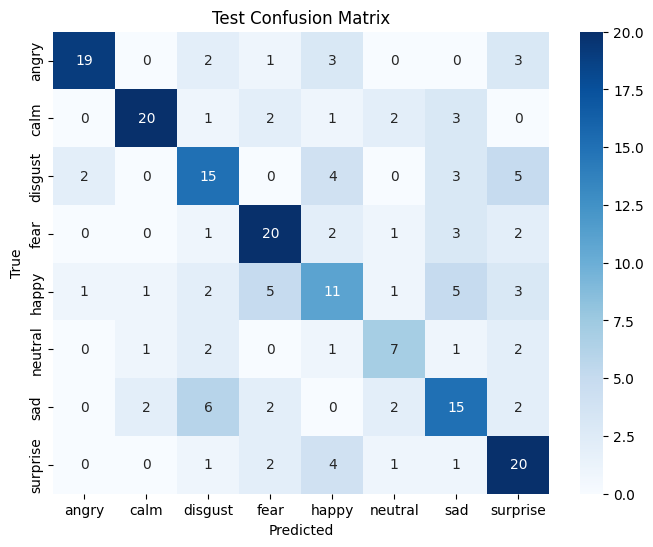

In [5]:
# eval_knn.py
import numpy as np
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

knn = joblib.load("models/knn/knn_model.pkl")
scaler = joblib.load("models/knn/scaler.pkl")
le = joblib.load("models/knn/label_encoder.pkl")

X_test  = np.load("data/processed_data/knn_and_nb/X_test.npy")
y_test  = np.load("data/processed_data/knn_and_nb/y_test.npy")

X_test_scaled = scaler.transform(X_test)

y_test_pred = knn.predict(X_test_scaled)

y_test_str = le.inverse_transform(y_test)
y_test_pred_str = le.inverse_transform(y_test_pred)

print("✅ Test Accuracy:", accuracy_score(y_test_str, y_test_pred_str))
print(classification_report(y_test_str, y_test_pred_str, target_names=le.classes_))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title("Test Confusion Matrix")
plt.show()


## 6. Čuvanje modela
- Sačuvani KNN model, scaler i label encoder.
- Omogućava kasniju evaluaciju bez ponovnog treniranja.

In [ ]:
joblib.dump(best_knn, "../models/knn/knn_model.pkl")
joblib.dump(scaler, "../models/knn/scaler.pkl")
joblib.dump(le, "../models/knn/label_encoder.pkl")
print("KNN model, scaler, label encoder and confusion matrices saved successfully.")

## * Augmentacija audio podataka

Augmentacija podataka je tehnika kojom veštački povećavamo broj trening uzoraka bez dodatnog sakupljanja novih podataka.  
Ovo je posebno korisno kod **audio klasifikacije** kada imamo mali ili neuravnotežen dataset.

### Zašto radimo augmentaciju:
- Pomaže modelu da **generalizuje** bolje.
- Smanjuje **overfitting**.
- Omogućava modelu da bude robustan na različite varijacije u audio signalu.

### Popularne tehnike za audio:
1. **Dodavanje šuma (Noise Injection)**  
   - Generiše se slučajan šum koji se dodaje originalnom signalu.  
   - Primer: `y_noisy = y + 0.005 * np.random.randn(len(y))`

2. **Pomak u vremenu (Time Shifting)**  
   - Signal se pomera unapred ili unazad za nekoliko milisekundi.  
   - Očuvava osnovne karakteristike, ali menja početak zvuka.

3. **Promena visine tona (Pitch Shifting)**  
   - Signal se podiže ili spušta za nekoliko polustepena.  
   - Model postaje robustan na različite tonove glasa.

4. **Promena brzine (Time Stretching)**  
   - Produžavanje ili skraćivanje trajanja zvuka bez promene visine tona.  
   - Korisno za varijacije govora ili muzike.

### Kako primenjujemo u praksi:
- Augmentaciju primenjujemo **samo na trening set**, nikada na validaciju ili test.  
- Možemo kombinovati više tehnika da stvorimo **bogatije trening podatke**.  
- Rezultat augmentacije je novi audio signal koji se koristi za ekstrakciju feature-a (npr. Mel spektrogram ili MFCC).

> * Napomena: Preterana augmentacija može dovesti do "lažnih" uzoraka koji zbunjuju model. Treba balansirati količinu i tip augmentacije.


In [ ]:
def add_noise(data, noise_factor=0.005):
    return data + noise_factor * np.random.randn(len(data))

def time_shift(data, shift_max=0.2):
    shift = np.random.randint(int(len(data) * -shift_max), int(len(data) * shift_max))
    return np.roll(data, shift)

def stretch(data, rate=None):
    if rate is None:
        rate = np.random.uniform(0.8, 1.2)
    return librosa.effects.time_stretch(data, rate=rate)

def pitch_shift(data, sr, n_steps=None):
    if n_steps is None:
        n_steps = np.random.uniform(-2, 2)
    return librosa.effects.pitch_shift(data, sr=sr, n_steps=n_steps)

def dynamic_change(data):
    factor = np.random.uniform(0.7, 1.3)
    return data * factor

## Rezultat pre augmentacije

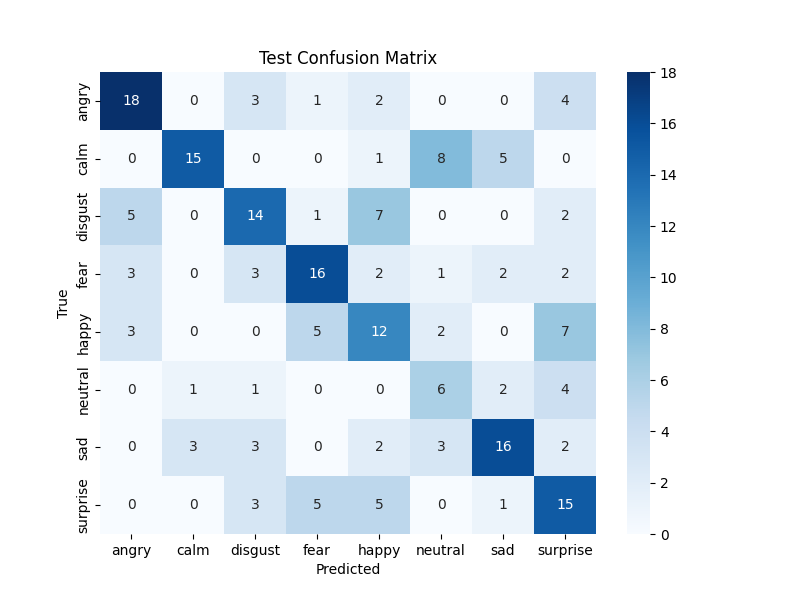

In [3]:
from IPython.display import Image, display

# Ime slike 
init = "models/knn/init_test_confusion_matrix.png"
# Prikaz slike
display(Image(filename=init))

## Zaključak za KNN model

1. Ukupna tačnost (Accuracy) je ~0.58, što znači da model prepoznaje emocije nešto više od polovine slučajeva. To nije visoka tačnost, ali može biti očekivano za ovako višeklasni problem sa audio signalima.

2. Performanse po klasama:

    - Najbolje prepoznate emocije su angry (0.77 F1) i calm (0.78 F1), što znači da model dobro razlikuje ove kategorije.

    - Slabije performanse imaju happy (0.36 F1), neutral (0.44 F1) i sad (0.42 F1), što pokazuje da model često greši kod ovih sličnijih ili manje zastupljenih emocija.

    - Surprise ima visok recall (0.76) ali nižu preciznost (0.54), što znači da model često predviđa ovu klasu, ali ne uvek tačno.

3. Nejednaka distribucija i mala količina podataka za neke klase (npr. neutral sa 14 uzoraka) verovatno doprinosi slabijem prepoznavanju.

4. Zaključak o modelu:

    - KNN je jednostavan i interpretabilan, ali za ovakav dataset sa više klasa i audio signalima njegova tačnost je ograničena.

    - Potencijalna poboljšanja:

        - Veći i balansiraniji dataset po klasama.

        - Razmotriti složenije modele (npr. Random Forest, CNN ili RNN) koji bolje hvataju audio obrasce.